**Dataset 1**

/tmp/ipykernel_531/29509396.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tag_counts.values, y=tag_counts.index, palette='viridis')


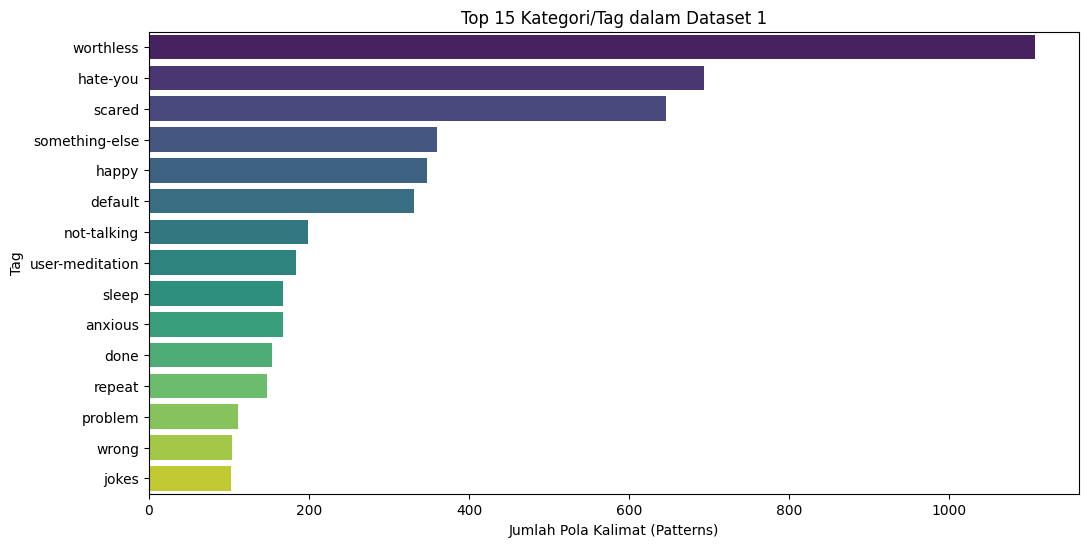

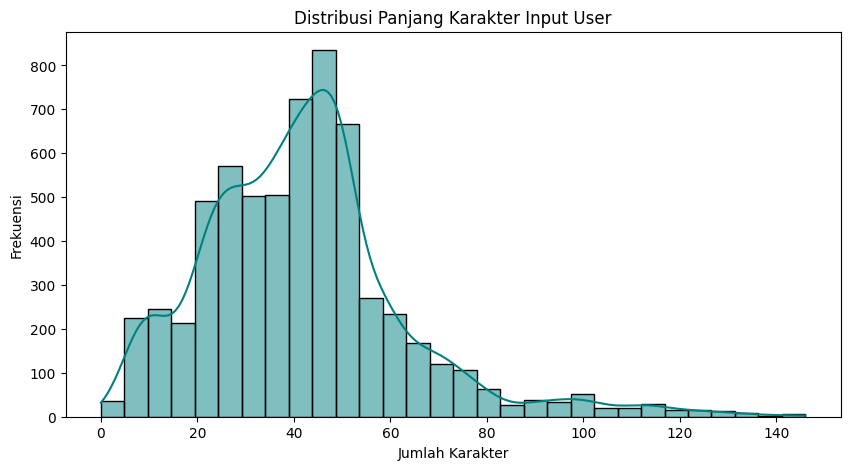

/tmp/ipykernel_531/29509396.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df1[df1['tag'].isin(top_10_tags)], x='tag', y='word_count', palette='Set3')


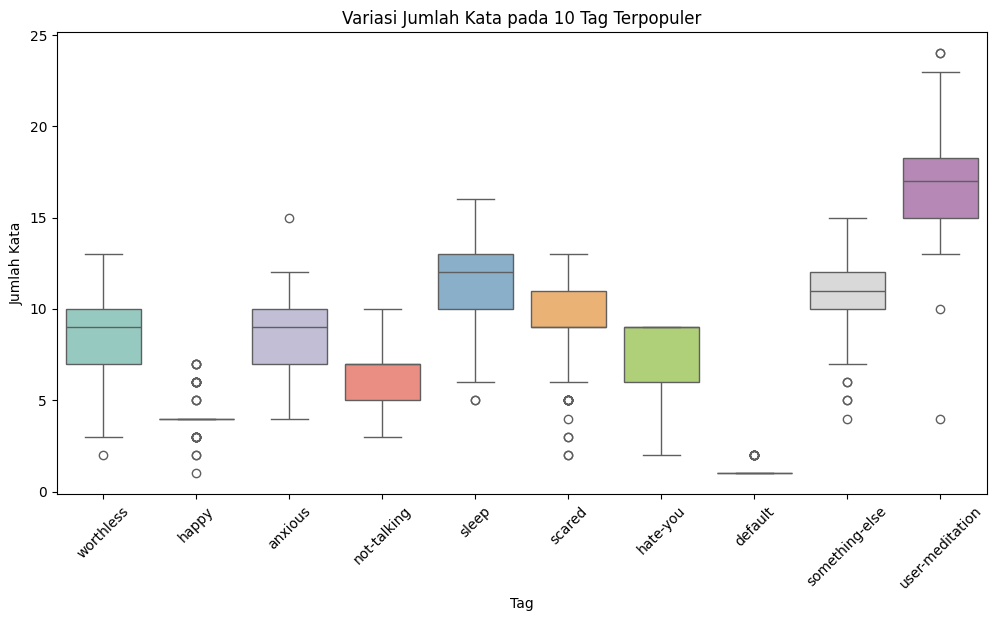


Preview data yang sudah diproses:
        tag              text  text_len  word_count
0  greeting                Hi         2           1
1  greeting               Hey         3           1
2  greeting  Is anyone there?        16           3
3  greeting          Hi there         8           2
4  greeting             Hello         5           1


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Memuat Data dari drive
url = "https://drive.google.com/uc?id=1EWGg-4q8eSOQaqB81BZ1__-IBham5kjN"
df_raw = pd.read_json(url)

# 2. Normalisasi Data (Mengubah struktur JSON 'intents' menjadi baris-baris DataFrame)
data_list = []
for intent in df_raw['intents']:
    tag = intent['tag']
    # ambil patterns (input user) sebagai basis data teks
    for pattern in intent['patterns']:
        data_list.append({
            'tag': tag,
            'text': pattern,
            'text_len': len(pattern),
            'word_count': len(pattern.split())
        })

df1 = pd.DataFrame(data_list)


# Visualisasi 1: Distribusi Kategori (Tag)
# Ini penting untuk melihat topik apa saja yang paling banyak pola kalimatnya (misal: solusi/gejala)
plt.figure(figsize=(12, 6))
tag_counts = df1['tag'].value_counts().head(15) # ini untuk mengambil 15 tag teratas agar tidak terlalu penuh
sns.barplot(x=tag_counts.values, y=tag_counts.index, palette='viridis')
plt.title('Top 15 Kategori/Tag dalam Dataset 1')
plt.xlabel('Jumlah Pola Kalimat (Patterns)')
plt.ylabel('Tag')
plt.show()

# Visualisasi 2: Distribusi Panjang Kalakter Patterns
# untuk memahami seberapa panjang biasanya orang berkonsultasi secara singkat
plt.figure(figsize=(10, 5))
sns.histplot(df1['text_len'], bins=30, kde=True, color='teal')
plt.title('Distribusi Panjang Karakter Input User')
plt.xlabel('Jumlah Karakter')
plt.ylabel('Frekuensi')
plt.show()

# Visualisasi 3: Boxplot Jumlah Kata per Tag (Top 10)
# melihat tag mana yang memiliki deskripsi lebih kompleks (misal: penjelasan gejala)
plt.figure(figsize=(12, 6))
top_10_tags = df1['tag'].value_counts().head(10).index
sns.boxplot(data=df1[df1['tag'].isin(top_10_tags)], x='tag', y='word_count', palette='Set3')
plt.xticks(rotation=45)
plt.title('Variasi Jumlah Kata pada 10 Tag Terpopuler')
plt.xlabel('Tag')
plt.ylabel('Jumlah Kata')
plt.show()

# Menampilkan 5 data teratas hasil pemrosesan
print("\nPreview data yang sudah diproses:")
print(df1.head())

/tmp/ipykernel_531/2966074399.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df2, x='status', palette='magma')


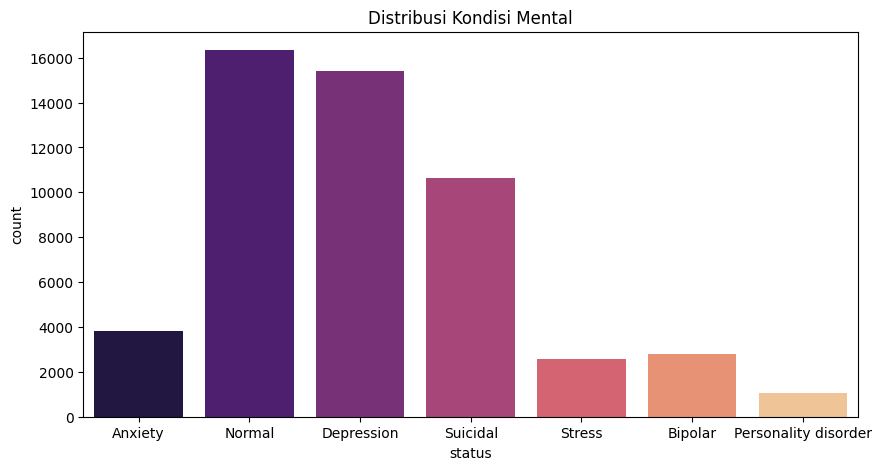

/tmp/ipykernel_531/2966074399.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df2, x='status', y='word_count', palette='Set2')


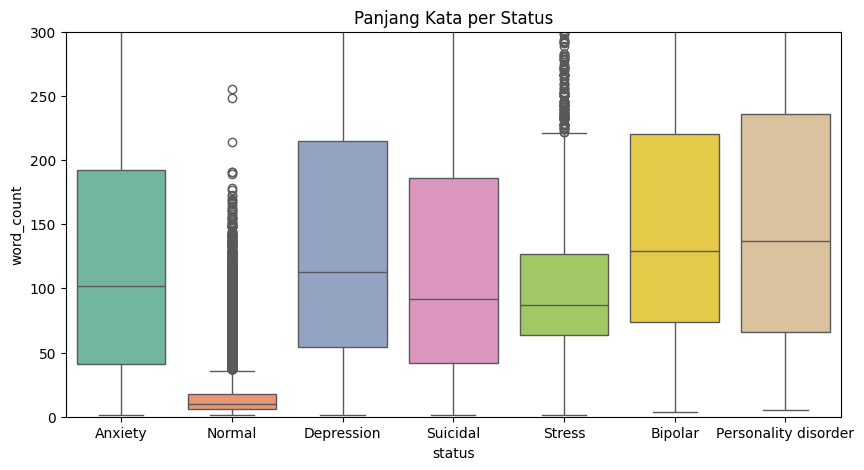

/tmp/ipykernel_531/2966074399.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequency', y='Bigram', data=b_df, palette='Reds_r')


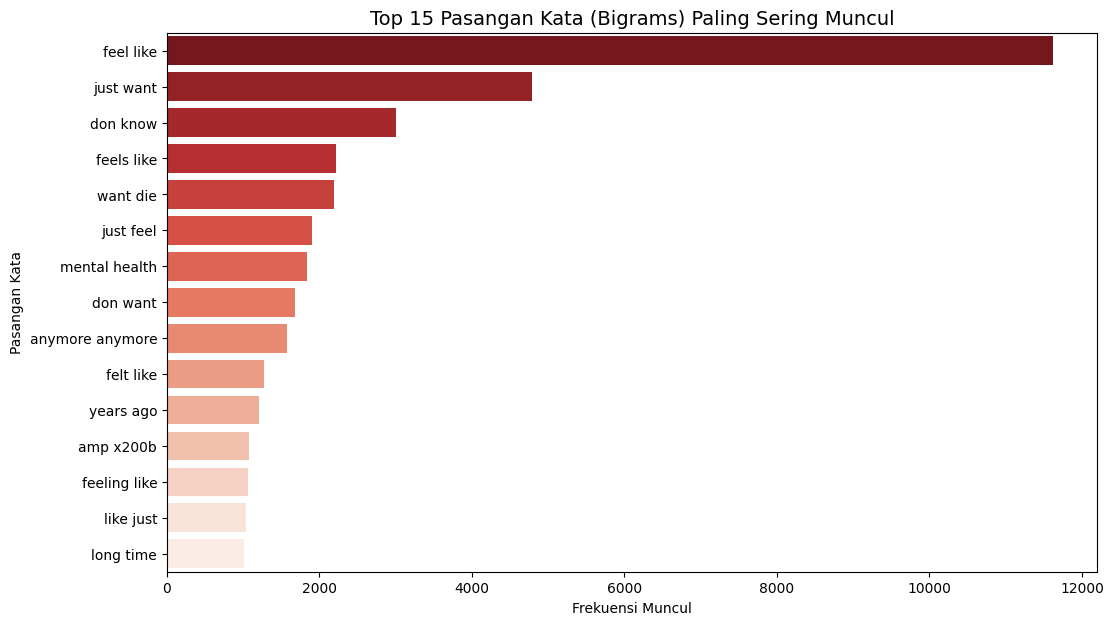

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer

# 1. Load Data dulu dari drive
url = "https://drive.google.com/uc?id=1bzjJRykwgXir6shdxr-mAzPNcQz9eIY1"
df2 = pd.read_csv(url)
df2 = df2.dropna(subset=['statement'])


# 1. Distribusi Status Mental dari dataset
plt.figure(figsize=(10, 5))
sns.countplot(data=df2, x='status', palette='magma')
plt.title('Distribusi Kondisi Mental')
plt.show()

# 2. Boxplot Panjang Kata
df2['word_count'] = df2['statement'].apply(lambda x: len(str(x).split()))
plt.figure(figsize=(10, 5))
sns.boxplot(data=df2, x='status', y='word_count', palette='Set2')
plt.ylim(0, 300)
plt.title('Panjang Kata per Status')
plt.show()


# Ini bentuknya bigrams membantu melihat pola gejala/keluhan yang lebih spesifik
def get_top_n_bigram(corpus, n=None):
    vec = CountVectorizer(ngram_range=(2, 2), stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:n]

top_bigrams = get_top_n_bigram(df2['statement'], n=15)
b_df = pd.DataFrame(top_bigrams, columns=['Bigram', 'Frequency'])

plt.figure(figsize=(12, 7))
sns.barplot(x='Frequency', y='Bigram', data=b_df, palette='Reds_r')
plt.title('Top 15 Pasangan Kata (Bigrams) Paling Sering Muncul', fontsize=14)
plt.xlabel('Frekuensi Muncul')
plt.ylabel('Pasangan Kata')
plt.show()